# 02 · Embeddings

上一章我们知道了 LLM 把文本切成 token。但模型无法直接处理文字，
它需要把每个 token 转成一串数字——这就是 **Embedding（嵌入）**。

Embedding 的神奇之处在于：**语义相近的文本，在向量空间里距离也近**。
这让「语义搜索」、「推荐系统」、「RAG」成为可能。

本章用代码把这个过程跑通，并做几个有趣的实验。

## 1. Embedding 是什么

Embedding 是一个**高维浮点数向量**，把文本的语义压缩进去。

```
"猫"   → [0.21, -0.54, 0.87, ...] （1536 维）
"猫咪" → [0.23, -0.51, 0.85, ...] （语义近，向量近）
"汽车" → [-0.62, 0.33, -0.14, ...]（语义远，向量远）
```

关键属性：
- **维度固定**：同一个模型输出的向量维度始终一样（如 1536 维）
- **长度归一化**：向量长度通常为 1（单位向量），方便计算相似度
- **语义可运算**：向量之间可以做加减法，结果有语义意义

In [1]:
import os
import numpy as np
from dotenv import load_dotenv
import litellm

load_dotenv()

def get_embedding(text: str, model: str = None) -> np.ndarray:
    """获取文本的 embedding 向量。"""
    # 根据 LLM_PROVIDER 自动选择 embedding 模型
    if model is None:
        llm_model = os.getenv("LLM_MODEL", "")
        if "anthropic" in llm_model:
            # Anthropic 没有独立 embedding API，用 OpenAI 兼容模型
            model = "openai/text-embedding-3-small"
        elif "gemini" in llm_model:
            model = "gemini/text-embedding-004"
        else:
            model = "openai/text-embedding-3-small"

    response = litellm.embedding(model=model, input=[text])
    return np.array(response.data[0]["embedding"])

# 试一试
vec = get_embedding("人工智能")
print(f"向量维度: {vec.shape}")
print(f"前 8 个值: {vec[:8].round(4)}")
print(f"向量模长: {np.linalg.norm(vec):.4f}")  # 应接近 1.0

向量维度: (1536,)
前 8 个值: [ 0.0143  0.0217  0.015   0.0176  0.0379 -0.0286 -0.014   0.0348]
向量模长: 0.9998


> **注意**：Anthropic 没有独立的 embedding API。
> 如果你的 `.env` 配置的是 Anthropic，需要额外设置 `OPENAI_API_KEY` 来运行本章的 embedding 部分。
> 或者把 `model` 参数改成你有权限的 embedding 模型。

## 2. 余弦相似度

两个向量的**余弦相似度**是衡量语义相近程度的标准方式：

$$\text{similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

- 结果范围：`-1` 到 `1`
- `1.0` → 完全相同方向（语义完全相似）
- `0.0` → 垂直（语义无关）
- `-1.0` → 完全相反方向（语义相反，实践中少见）

因为 embedding 通常已归一化（模长=1），所以余弦相似度就等于**点积**。

In [2]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """计算两个向量的余弦相似度。"""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# 几组对比
pairs = [
    ("猫",     "猫咪"),
    ("猫",     "狗"),
    ("猫",     "汽车"),
    ("人工智能", "AI"),
    ("人工智能", "机器学习"),
    ("人工智能", "足球"),
    ("happy",  "sad"),
    ("happy",  "joyful"),
]

print(f"{'文本 A':12} {'文本 B':12} {'相似度':>8}")
print("-" * 38)
for a, b in pairs:
    sim = cosine_similarity(get_embedding(a), get_embedding(b))
    bar = "█" * int(sim * 20)
    print(f"{a:12} {b:12} {sim:8.4f}  {bar}")

文本 A         文本 B              相似度
--------------------------------------
猫            猫咪             0.7639  ███████████████
猫            狗              0.6647  █████████████
猫            汽车             0.4200  ████████
人工智能         AI             0.4651  █████████
人工智能         机器学习           0.5746  ███████████
人工智能         足球             0.2161  ████
happy        sad            0.6101  ████████████
happy        joyful         0.6350  ████████████


## 3. 语义搜索

Embedding 最直接的应用：给一个查询，从一堆文本里找最相关的。
这就是 **RAG（检索增强生成）** 的核心机制。

In [3]:
# 知识库：一些句子
documents = [
    "Python 是一种广泛用于数据科学和 AI 的编程语言。",
    "猫是一种独立性强的宠物，通常不需要太多照料。",
    "深度学习是机器学习的一个子领域，使用神经网络。",
    "巴黎是法国的首都，以埃菲尔铁塔闻名。",
    "Transformer 架构彻底改变了自然语言处理领域。",
    "足球是世界上最受欢迎的运动之一。",
    "向量数据库专门用于存储和检索高维向量。",
    "咖啡含有咖啡因，能帮助人保持清醒。",
]

# 预计算所有文档的 embedding
print("正在计算文档 embeddings...")
doc_embeddings = [get_embedding(doc) for doc in documents]
print(f"完成，共 {len(doc_embeddings)} 个向量")

正在计算文档 embeddings...
完成，共 8 个向量


In [4]:
def semantic_search(query: str, top_k: int = 3) -> list:
    """语义搜索：返回最相关的 top_k 个文档。"""
    query_emb = get_embedding(query)
    scores = [
        (cosine_similarity(query_emb, doc_emb), doc)
        for doc_emb, doc in zip(doc_embeddings, documents)
    ]
    scores.sort(reverse=True)
    return scores[:top_k]

# 测试几个查询
queries = [
    "如何学习机器学习？",
    "我想养一只小动物",
    "LLM 的底层原理是什么？",
]

for query in queries:
    print(f"\n🔍 查询: {query}")
    results = semantic_search(query)
    for i, (score, doc) in enumerate(results, 1):
        print(f"  {i}. [{score:.4f}] {doc}")


🔍 查询: 如何学习机器学习？
  1. [0.5247] 深度学习是机器学习的一个子领域，使用神经网络。
  2. [0.3096] Python 是一种广泛用于数据科学和 AI 的编程语言。
  3. [0.2460] Transformer 架构彻底改变了自然语言处理领域。

🔍 查询: 我想养一只小动物
  1. [0.3414] 猫是一种独立性强的宠物，通常不需要太多照料。
  2. [0.1822] 深度学习是机器学习的一个子领域，使用神经网络。
  3. [0.1636] Python 是一种广泛用于数据科学和 AI 的编程语言。

🔍 查询: LLM 的底层原理是什么？
  1. [0.3256] 深度学习是机器学习的一个子领域，使用神经网络。
  2. [0.2734] Transformer 架构彻底改变了自然语言处理领域。
  3. [0.1538] 咖啡含有咖啡因，能帮助人保持清醒。


注意：查询「如何学习机器学习？」能找到关于深度学习和 Transformer 的文档，
即使它们没有共同的关键词——这就是**语义搜索**比关键词搜索强的地方。

## 4. 有趣实验：向量运算有语义

著名的 Word2Vec 实验：`king - man + woman ≈ queen`

这说明 embedding 空间里的**方向**是有意义的，
比如「男性→女性」的方向在向量空间里是一致的。

In [5]:
# 预先获取所有需要的词的 embedding
words = ["king", "man", "woman", "queen", "prince", "princess",
         "actor", "actress", "uncle", "aunt"]
word_embeddings = {w: get_embedding(w) for w in words}

def analogy(a: str, b: str, c: str, candidates: list) -> str:
    """
    a - b + c = ?
    例：king - man + woman = ?
    """
    target = word_embeddings[a] - word_embeddings[b] + word_embeddings[c]
    # 归一化
    target = target / np.linalg.norm(target)
    
    best_word, best_score = "", -1
    for word in candidates:
        if word in (a, b, c):
            continue
        score = cosine_similarity(target, word_embeddings[word])
        if score > best_score:
            best_score, best_word = score, word
    return best_word, best_score

analogies = [
    ("king",   "man",   "woman"),    # → queen
    ("prince", "man",   "woman"),    # → princess
    ("actor",  "man",   "woman"),    # → actress
    ("uncle",  "man",   "woman"),    # → aunt
]

print(f"{'公式':30} {'预测':10} {'相似度':>8}")
print("-" * 52)
for a, b, c in analogies:
    result, score = analogy(a, b, c, words)
    formula = f"{a} - {b} + {c}"
    print(f"{formula:30} {result:10} {score:8.4f}")

公式                             预测              相似度
----------------------------------------------------
king - man + woman             queen        0.6161
prince - man + woman           princess     0.6849
actor - man + woman            actress      0.6339
uncle - man + woman            aunt         0.6909


## 5. 可视化：PCA 降维到 2D

1536 维的向量没法直接看，用 **PCA** 压缩到 2 维后可以画出来，
直观感受哪些词在语义空间里「住得近」。

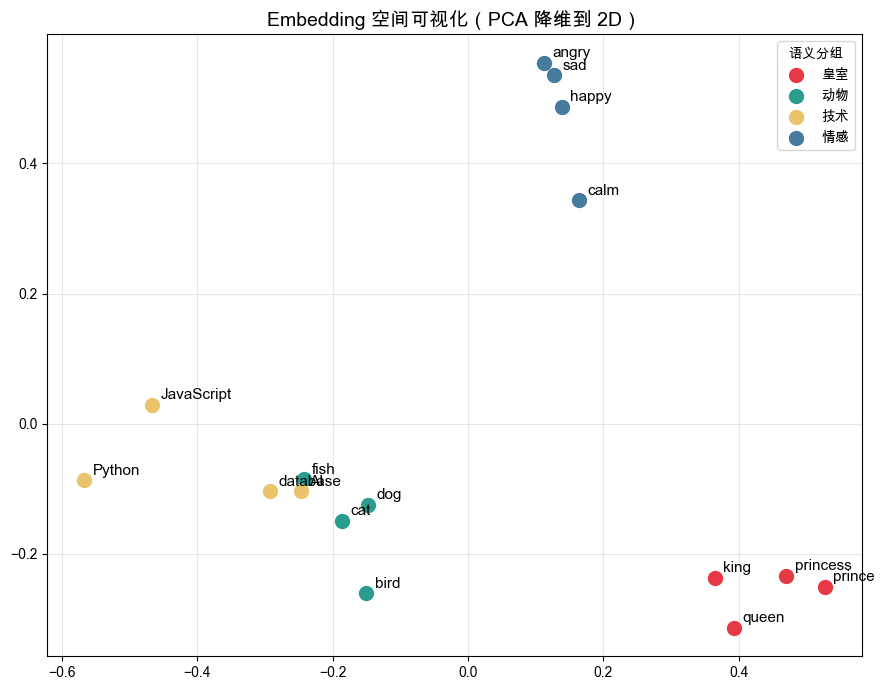

PCA 保留方差: 28.4%


In [6]:
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA

matplotlib.rcParams["font.family"] = ["Arial Unicode MS", "sans-serif"]

# 准备词组
groups = {
    "皇室": ["king", "queen", "prince", "princess"],
    "动物": ["cat", "dog", "bird", "fish"],
    "技术": ["Python", "JavaScript", "AI", "database"],
    "情感": ["happy", "sad", "angry", "calm"],
}

all_words = [w for ws in groups.values() for w in ws]
all_embs  = [get_embedding(w) for w in all_words]

# PCA 降维
pca = PCA(n_components=2)
coords = pca.fit_transform(np.array(all_embs))

# 画图
colors = ["#E63946", "#2A9D8F", "#E9C46A", "#457B9D"]
fig, ax = plt.subplots(figsize=(9, 7))

idx = 0
for (group_name, group_words), color in zip(groups.items(), colors):
    n = len(group_words)
    xs = coords[idx:idx+n, 0]
    ys = coords[idx:idx+n, 1]
    ax.scatter(xs, ys, color=color, s=100, label=group_name, zorder=3)
    for x, y, word in zip(xs, ys, group_words):
        ax.annotate(word, (x, y), textcoords="offset points",
                    xytext=(6, 4), fontsize=11)
    idx += n

ax.set_title("Embedding 空间可视化（PCA 降维到 2D）", fontsize=14)
ax.legend(title="语义分组")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"PCA 保留方差: {pca.explained_variance_ratio_.sum():.1%}")

## 6. 用 LLM 结合 Embedding 做问答

把「语义搜索」和「LLM 生成」串起来，这就是最简单的 RAG 雏形：
先检索，再生成。

In [7]:
from utils.llm_client import chat

def rag_answer(question: str, top_k: int = 2) -> str:
    """最简单的 RAG：检索相关文档 → 送给 LLM 生成答案。"""
    # 1. 检索
    results = semantic_search(question, top_k=top_k)
    context = "\n".join(f"- {doc}" for _, doc in results)

    # 2. 生成
    prompt = f"""根据以下参考资料回答问题，只使用资料中的信息，不要发挥。

参考资料：
{context}

问题：{question}
回答："""
    return chat(prompt)

question = "LLM 和神经网络有什么关系？"
print(f"问题: {question}")
print(f"\n答案:\n{rag_answer(question)}")

问题: LLM 和神经网络有什么关系？

答案:
根据资料中的信息：

- 深度学习使用神经网络。  
- Transformer 架构彻底改变了自然语言处理领域。

因此，可以得出一个基于资料的推断性结论：如果 LLM 使用 Transformer 这类在自然语言处理上被广泛采用的架构，那么 LLM 就属于深度学习的范畴，从而依赖神经网络。


## 小结

| 概念 | 要点 |
|------|------|
| Embedding | 将文本映射为固定维度的浮点向量，语义相近则向量相近 |
| 余弦相似度 | 衡量两个向量方向的接近程度，范围 -1 到 1 |
| 语义搜索 | 用 embedding 找语义最相近的文档，不依赖关键词匹配 |
| 向量运算 | embedding 空间的方向有意义，支持类比推理 |
| RAG 雏形 | 检索 → 生成，是 Module 4 RAG 章节的基础 |

**下一章 →** [Context Window](03_context_window.ipynb)：上下文窗口的本质、限制与实战策略